In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import drive

drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/Proiect_Licenta_XAUUSD'

df = pd.read_csv(f"{PROJECT_PATH}/data/processed/XAUUSD_with_indicators.csv", index_col=0, parse_dates=True)

prediction_horizon = 3
df['target'] = (df['close'].shift(-prediction_horizon) / df['close']) - 1
df = df.dropna()

features = [
    'dist_ema_200', 'atr', 'bb_pct', 'fix_vix', 'is_vix_green', 
    'smi_oversold', 'smi_overbought', 'ret_1h', 'ret_3h', 'hour', 'day_of_week'
]
smi_col = [c for c in df.columns if 'smi' in c and 'over' not in c and '_s' not in c][0]
features.append(smi_col)

X = df[features]
y = df['target']

# Split 80/20
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

model_xgb = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist' 
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)
#Predictions 
y_pred_xgb = model_xgb.predict(X_test)

# Evaluation
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("-" * 30)
print(f"XGBOOST RESULTS:")
print(f"RMSE: {rmse_xgb:.6f}")
print(f"R2 Score: {r2_xgb:.6f}")

[0]	validation_0-rmse:0.00375
[50]	validation_0-rmse:0.00376
[100]	validation_0-rmse:0.00379
[150]	validation_0-rmse:0.00380
[200]	validation_0-rmse:0.00381
[250]	validation_0-rmse:0.00382
[300]	validation_0-rmse:0.00383
[350]	validation_0-rmse:0.00384
[400]	validation_0-rmse:0.00385
[450]	validation_0-rmse:0.00386
[499]	validation_0-rmse:0.00387
------------------------------
XGBOOST RESULTS:
RMSE: 0.003866
R2 Score: -0.064997


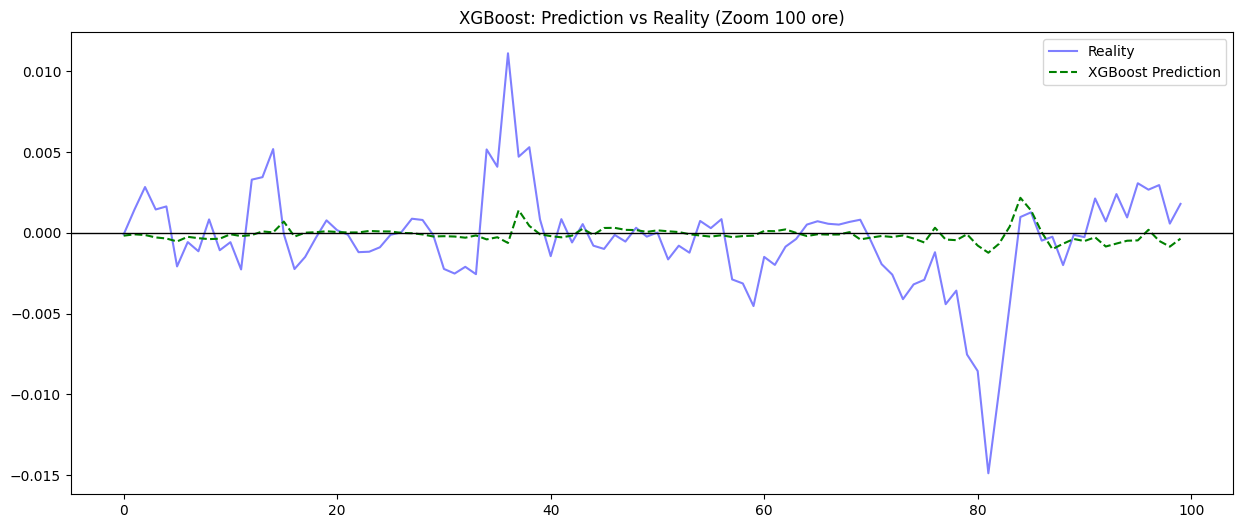

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:100], label='Reality', color='blue', alpha=0.5)
plt.plot(y_pred_xgb[:100], label='XGBoost Prediction', color='green', linestyle='--')
plt.axhline(0, color='black', lw=1)
plt.title('XGBoost: Prediction vs Reality (Zoom 100 hours)')
plt.legend()
plt.show()

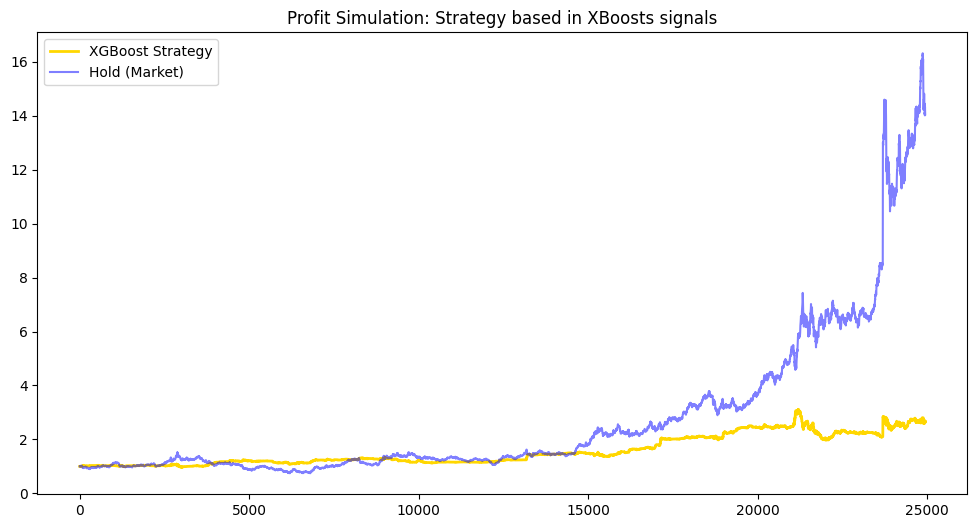

Win Rate: 51.26%
Total number of tranzactions: 7083


In [4]:

threshold = 0.0005 

# Signal columns: 1 (Buy), -1 (Sell), 0 (Wait)
y_pred_series = pd.Series(y_pred_xgb, index=X_test.index)
signals = np.where(y_pred_series > threshold, 1, 
          np.where(y_pred_series < -threshold, -1, 0))


strategy_returns = signals * y_test


cumulative_strategy = (1 + strategy_returns).cumprod()
cumulative_market = (1 + y_test).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cumulative_strategy.values, label='XGBoost Strategy', color='gold', lw=2)
plt.plot(cumulative_market.values, label='Hold (Market)', color='blue', alpha=0.5)
plt.title('Profit Simulation: Strategy based in XBoosts signals')
plt.legend()
plt.show()

win_rate = (strategy_returns > 0).sum() / (signals != 0).sum()
print(f"Win Rate: {win_rate:.2%}")
print(f"Total number of tranzactions: {(signals != 0).sum()}")

In [5]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500, 1000],
    'colsample_bytree': [0.3, 0.7, 1.0],
    'subsample': [0.5, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_distributions=param_grid,
    n_iter=10, 
    scoring='neg_mean_squared_error',
    cv=3, # Validation in 3 steps
    verbose=1,
    n_jobs=-1
)

print(" We are searching for the best setting for XGBoost")
xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
print(f"The best settings: {xgb_search.best_params_}")

y_pred_opt = best_xgb.predict(X_test)
r2_opt = r2_score(y_test, y_pred_opt)
print(f"The new R2 score after optimization: {r2_opt:.6f}")

 We are searching for the best setting for XGBoost
Fitting 3 folds for each of 10 candidates, totalling 30 fits
The best settings: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.3}
The new R2 score after optimization: 0.000086


In [6]:
import joblib

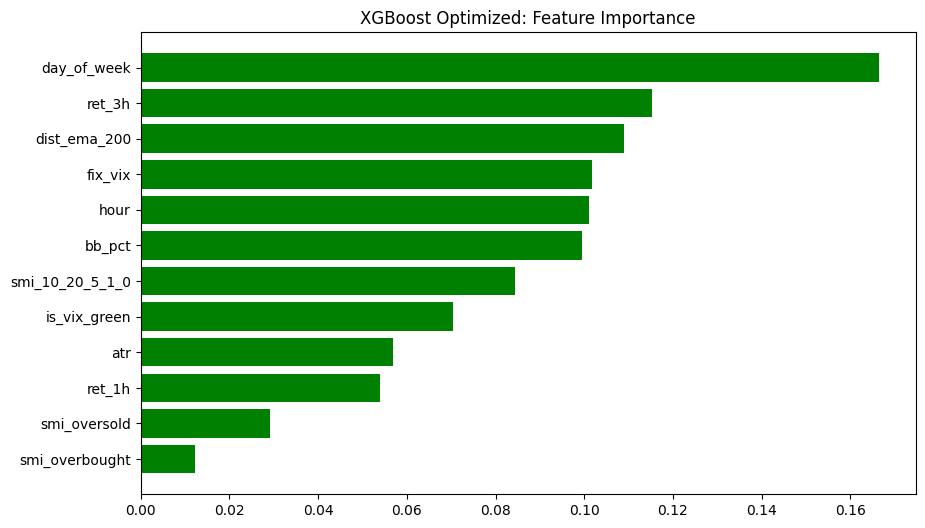

['/content/drive/MyDrive/Proiect_Licenta_XAUUSD/models/xgboost_optimized_v1.pkl']

In [7]:
# The importance of features
xgb_importances = best_xgb.feature_importances_
df_imp_xgb = pd.DataFrame({'Feature': features, 'Importance': xgb_importances})
df_imp_xgb = df_imp_xgb.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(df_imp_xgb['Feature'], df_imp_xgb['Importance'], color='green')
plt.title('XGBoost Optimized: Feature Importance')
plt.gca().invert_yaxis()
plt.show()

joblib.dump(best_xgb, f"{PROJECT_PATH}/models/xgboost_optimized_v1.pkl")